# Tesla Deliveries and Production Data Analysis

## Objective
Analyze Tesla deliveries and production trends using machine learning and time series forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raws/tesla_deliveries_dataset_2015_2025.csv")

In [2]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


DATA PREPROCESSING

In [3]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())


(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')
Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [4]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df[['Year', 'Month', 'Date']].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


In [5]:
df = df.sort_values('Date')
df.reset_index(drop=True, inplace=True)

df[['Date', 'Estimated_Deliveries']].head()

,Date,Estimated_Deliveries
0,2015-01-01,12446
1,2015-01-01,11446
2,2015-01-01,8803
3,2015-01-01,6367
4,2015-01-01,8795


EXPLORATORY DATA ANALYSIS

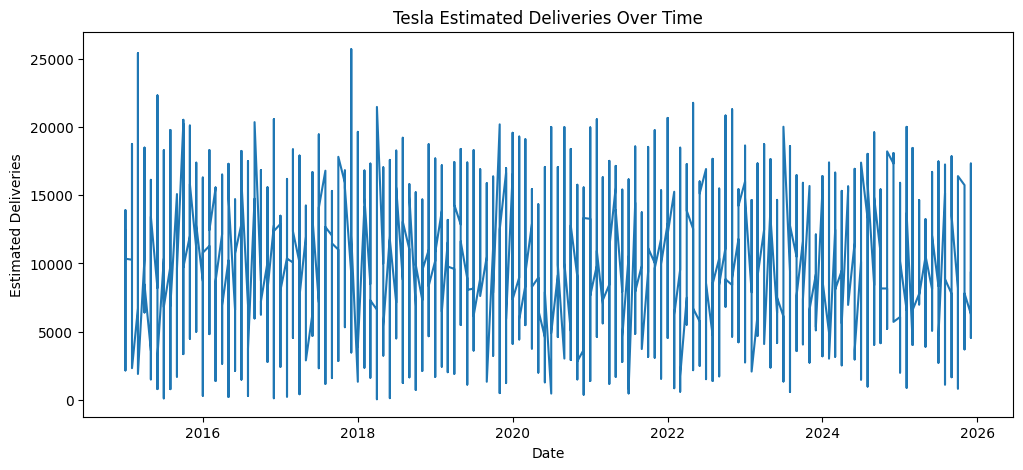

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Estimated_Deliveries'])

plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

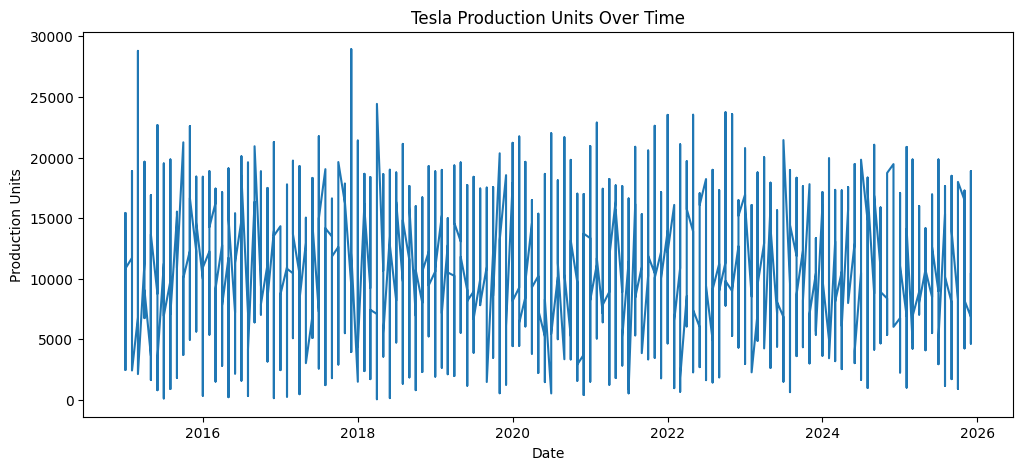

In [7]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Production_Units'])

plt.title("Tesla Production Units Over Time")
plt.xlabel("Date")
plt.ylabel("Production Units")

plt.show()

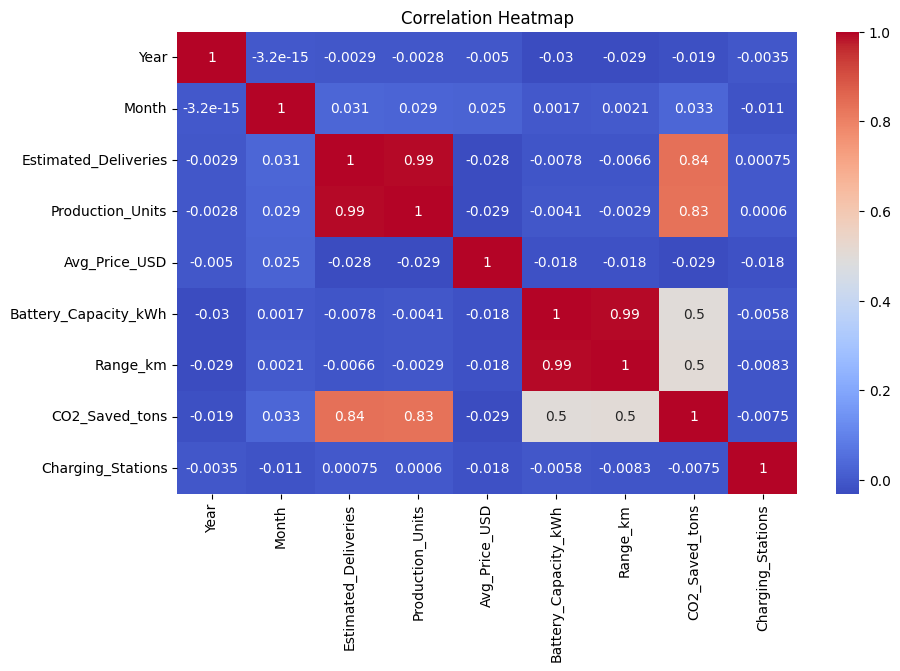

In [8]:
# HEATMAP
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

FEATURE ENGINEERING

In [9]:
# Create lag features
df['Lag_1_Deliveries'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2_Deliveries'] = df['Estimated_Deliveries'].shift(2)
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

# Growth rate
df['Growth_Rate'] = df['Estimated_Deliveries'].pct_change()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Lag_1_Deliveries,Lag_2_Deliveries,Rolling_Mean_3,Growth_Rate
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,NaN,NaN,NaN,NaN
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,12446.0,NaN,NaN,-0.080347
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0,12446.0,10898.333333,-0.230910
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0,11446.0,8872.000000,-0.276724
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0,8803.0,7988.333333,0.381341


In [10]:

df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
Lag_1_Deliveries        1
Lag_2_Deliveries        2
Rolling_Mean_3          2
Growth_Rate             1
dtype: int64

In [11]:
df = df.dropna()

df.reset_index(drop=True, inplace=True)

df.shape

(2638, 17)

In [12]:
X = df.drop(columns=['Estimated_Deliveries', 'Date'])

# Target
y = df['Estimated_Deliveries']

print(X.shape)
print(y.shape)

(2638, 15)
(2638,)


In [13]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2110, 15)
Testing set: (528, 15)


TRAIN MODEL


LINEAR REGRESSION

In [14]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

ValueError: could not convert string to float: 'Middle East'

In [ ]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
print(y_pred_lr[:5])

[ 8910. 10819.  5341.  8195.  8179.]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.2069752604778236e-11
RMSE: 1.4552076714456226e-11
R2 Score: 1.0


RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Model
- Region
- Source_Type
Feature names seen at fit time, yet now missing:
- Model_Model 3
- Model_Model S
- Model_Model X
- Model_Model Y
- Region_Europe
- ...


In [ ]:
# Model comparison table

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
})

results